In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
data = pd.read_csv('/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/Demographic/demographic.csv')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 22, number of negative: 80
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53
[LightGBM] [Info] Number of data points in the train set: 102, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.215686 -> initscore=-1.290984
[LightGBM] [Info] Start training from score -1.290984
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

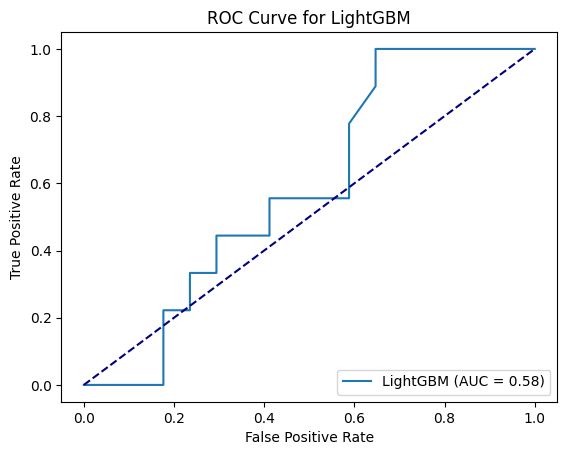

ROC AUC Score: 0.58
Accuracy: 0.54
Confusion Matrix:
[[14  3]
 [ 9  0]]


In [3]:
# Step 4: Train-Test Split
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix

X = data.drop(columns=['Delirium at any time during hospitalization'], inplace=False)
y = data['Delirium at any time during hospitalization']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train LightGBM Model
lgbm_model = LGBMClassifier(random_state=42, n_estimators=100)
lgbm_model.fit(X_train, y_train)

# Step 6: Make Predictions and Evaluate Model
y_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]
y_pred = lgbm_model.predict(X_test)

# Calculate AUC-ROC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Step 7: Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LightGBM')
plt.legend(loc='lower right')
plt.show()

# Step 8: Output Additional Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'ROC AUC Score: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)


/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 22, number of negative: 80
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57
[LightGBM] [Info] Number of data points in the train set: 102, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.215686 -> initscore=-1.290984
[LightGBM] [Info] Start training from score -1.290984
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

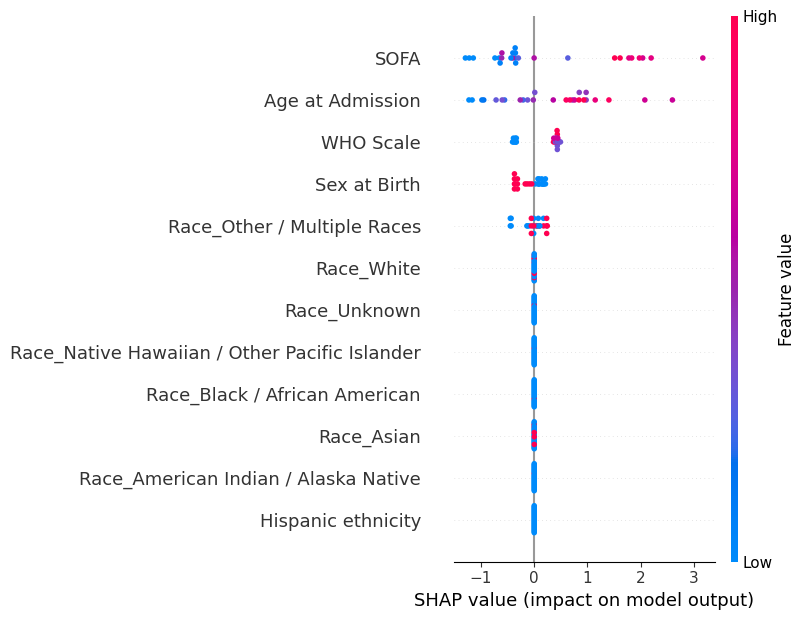

In [4]:
import shap
from sklearn.preprocessing import StandardScaler

# Step 9: Standardize the numerical features for SHAP (Optional, depending on the logistic regression convergence)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Step 10: Fit model on scaled data (replace original model with one trained on scaled data)
lgbm_model.fit(X_train_scaled, y_train)

# Step 11: Initialize SHAP explainer and calculate SHAP values for the test set
explainer = shap.Explainer(lgbm_model, X_train_scaled)
shap_values = explainer(X_test_scaled, check_additivity=False)

# Step 12: Plot SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot", show=True)

In [5]:
X_gbm = data[['WHO Scale', 'SOFA', 'Sex at Birth']]
y_gbm = data['Delirium at any time during hospitalization']

In [6]:
X_trainGBM, X_testGBM, y_trainGBM, y_testGBM = train_test_split(X_gbm, y_gbm, test_size=0.2, random_state=42)

model = LGBMClassifier(random_state=42)
model.fit(X_trainGBM, y_trainGBM)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 22, number of negative: 80
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000508 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22
[LightGBM] [Info] Number of data points in the train set: 102, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.215686 -> initscore=-1.290984
[LightGBM] [Info] Start training from score -1.290984
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

LGBMClassifier(random_state=42)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 22, number of negative: 80
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22
[LightGBM] [Info] Number of data points in the train set: 102, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.215686 -> initscore=-1.290984
[LightGBM] [Info] Start training from score -1.290984
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

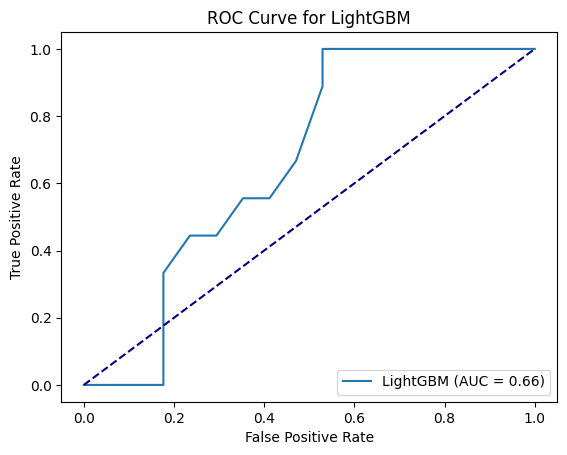

ROC AUC Score: 0.66
Accuracy: 0.62
Confusion Matrix:
[[14  3]
 [ 7  2]]


In [7]:
# Step 5: Train LightGBM Model
lgbm_model.fit(X_trainGBM, y_trainGBM)

# Step 6: Make Predictions and Evaluate Model
y_pred_probaGBM = lgbm_model.predict_proba(X_testGBM)[:, 1]
y_predGBM = lgbm_model.predict(X_testGBM)

# Calculate AUC-ROC score
roc_auc = roc_auc_score(y_testGBM, y_pred_probaGBM)

# Step 7: Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_testGBM, y_pred_probaGBM)
plt.figure()
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LightGBM')
plt.legend(loc='lower right')
plt.show()

# Step 8: Output Additional Metrics
accuracyGBM = accuracy_score(y_testGBM, y_predGBM)
conf_matrixGBM = confusion_matrix(y_testGBM, y_predGBM)

print(f'ROC AUC Score: {roc_auc:.2f}')
print(f'Accuracy: {accuracyGBM:.2f}')
print('Confusion Matrix:')
print(conf_matrixGBM)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 22, number of negative: 80
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24
[LightGBM] [Info] Number of data points in the train set: 102, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.215686 -> initscore=-1.290984
[LightGBM] [Info] Start training from score -1.290984
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

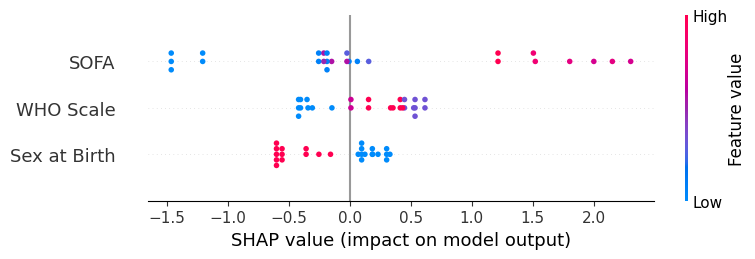

In [8]:
import shap
from sklearn.preprocessing import StandardScaler

# Step 9: Standardize the numerical features for SHAP (Optional, depending on the logistic regression convergence)
scaler = StandardScaler()
X_train_scaledGBM = pd.DataFrame(scaler.fit_transform(X_trainGBM), columns=X_trainGBM.columns, index=X_trainGBM.index)
X_test_scaledGBM = pd.DataFrame(scaler.transform(X_testGBM), columns=X_testGBM.columns, index=X_testGBM.index)

# Step 10: Fit model on scaled data (replace original model with one trained on scaled data)
model.fit(X_train_scaledGBM, y_trainGBM)

# Step 11: Initialize SHAP explainer and calculate SHAP values for the test set
explainer = shap.Explainer(model, X_train_scaledGBM)
shap_valuesGBM = explainer(X_test_scaledGBM, check_additivity=False)

# Step 12: Plot SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_valuesGBM, X_test_scaledGBM, plot_type="dot", show=True)